In [ ]:
#%% Load Library

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
#%% Function

def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY) 

def prepare_data(dir, store_id):
    df = pd.read_csv(dir,parse_dates = ["date"], index_col = [0])
    df = df[df['store_id'] == store_id]
    df = df.drop(columns=['count','store_id'])
    for col in df.columns:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    test_split=round(len(df)*0.20)
    df_for_training=df[:-test_split]
    df_for_testing=df[-test_split:]
    

    df_for_training_scaled = scaler.fit_transform(df_for_training)
    df_for_testing_scaled=scaler.transform(df_for_testing)
    trainX,trainY=createXY(df_for_training_scaled,30)

    testX,testY=createXY(df_for_testing_scaled,30)
    return trainX, trainY, testX, testY

def build_model(optimizer='adam'):
    grid_model = Sequential()
    grid_model.add(LSTM(50, return_sequences=True, input_shape=(30, 64)))
    grid_model.add(LSTM(50))
    grid_model.add(Dropout(0.2))
    grid_model.add(Dense(1))

    grid_model.compile(loss='mse', optimizer=optimizer)
    return grid_model

def train_model(model, train_x, train_y):

    grid_model = KerasRegressor(build_fn=model, verbose=1)
    parameters = {'batch_size': [16, 20],
                'epochs': [8, 10],
                'optimizer': ['adam', 'Adadelta']}

    grid_search = GridSearchCV(estimator=grid_model,
                            param_grid=parameters,
                            cv=2)
    grid_search = grid_search.fit(train_x, train_y)

    return grid_search

def calculate_permutation_importance(model, X, y, feature_names, n_repeats=10, random_state=42):
    """
    Calculate permutation importance for an LSTM model.
    
    Parameters:
    -----------
    model : Keras model
        Trained LSTM model
    X : numpy array
        Feature data in the shape expected by the LSTM model
    y : numpy array
        Target values
    feature_names : list
        Names of features corresponding to the last dimension of X
    n_repeats : int, default=10
        Number of times to permute each feature
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    dict
        Dictionary with feature names as keys and importance scores as values
    """
    import numpy as np
    from sklearn.metrics import mean_squared_error
    import copy
    import random
    
    # Set random seed for reproducibility
    np.random.seed(random_state)
    random.seed(random_state)
    
    # Calculate baseline score
    baseline_pred = model.predict(X)
    baseline_score = mean_squared_error(y, baseline_pred)
    
    # Store importance scores
    importance_dict = {}
    
    # Get the feature dimension (assuming X shape is [samples, timesteps, features])
    n_samples, n_timesteps, n_features = X.shape
    
    # Verify feature_names length matches n_features
    if len(feature_names) != n_features:
        raise ValueError(f"Length of feature_names ({len(feature_names)}) doesn't match number of features in X ({n_features})")
    
    # Calculate importance for each feature
    for feature_idx in range(n_features):
        feature_name = feature_names[feature_idx]
        importance_scores = []
        
        for _ in range(n_repeats):
            # Create a copy of the data
            X_permuted = copy.deepcopy(X)
            
            # Permute the feature across all timesteps
            for t in range(n_timesteps):
                perm_idx = np.random.permutation(n_samples)
                X_permuted[:, t, feature_idx] = X_permuted[perm_idx, t, feature_idx]
            
            # Predict with permuted feature
            perm_pred = model.predict(X_permuted)
            
            # Calculate new score
            perm_score = mean_squared_error(y, perm_pred)
            
            # Calculate importance (increase in error)
            importance = perm_score - baseline_score
            importance_scores.append(importance)
        
        # Average importance across repeats
        importance_dict[feature_name] = np.mean(importance_scores)
    
    # Normalize to sum to 1 (optional)
    total_importance = sum(importance_dict.values())
    if total_importance > 0:  # Avoid division by zero
        for feature in importance_dict:
            importance_dict[feature] /= total_importance
    
    # Sort by importance (descending)
    importance_dict = dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))
    
    return importance_dict



def calculate_feature_importance(store, model, testX, testY, feature_names):
    """
    Wrapper function to calculate and visualize feature importance
    """
    import matplotlib.pyplot as plt
    
    # Calculate permutation importance
    importance_dict = calculate_permutation_importance(model, testX, testY, feature_names)
    
    # Print importance scores
    print(f"\nFeature Importance for Store {store}:")
    for feature, importance in importance_dict.items():
        print(f"{feature}: {importance:.4f}")
    
    # Plot feature importance
    plt.figure(figsize=(15, 10))
    features = list(importance_dict.keys())
    importances = list(importance_dict.values())
    
    plt.barh(features, importances)
    plt.xlabel('Importance')
    plt.title(f'Feature Importance for Store {store}')
    plt.tight_layout()
    plt.savefig(f'../output/feature_importance_store_{store}.png')
    plt.show()
    
    return importance_dict

Training begin CA_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0381
Epoch 2/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0180
Epoch 3/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0158
Epoch 4/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0109
Epoch 5/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0086
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0078
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0069
Epoch 8/8
47/47 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 10ms/step - loss: 0.0389
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0150
Epoch 3/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0123
Epoch 4/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0100
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0071
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0071
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0064
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0563
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0196
Epoch 3/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0183
Epoch 4/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0133
Epoch 5/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0105
Epoch 6/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0091
Epoch 7/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0082
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0078
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0070
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0459
Epoch 2/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0156
Epoch 3/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0134
Epoch 4/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0108
Epoch 5/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0090
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0070
Epoch 7/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0072
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0068
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0063
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 13ms/step - loss: 0.0281
Epoch 2/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0121
Epoch 3/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0080
Epoch 4/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0068
Epoch 5/10
94/94 [==============================] - 1s 13ms/step - loss: 0.0069
Epoch 6/10
94/94 [==============================] - 1s 13ms/step - loss: 0.0065
Epoch 7/10
94/94 [==============================] - 1s 13ms/step - loss: 0.0058
Epoch 8/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0055
Epoch 9/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0056
Epoch 10/10
12/12 [==============================] - 0s 4ms/step

Feature Importance for Store CA_1:
weekday_Sunday: 0.3405
weekday_Friday: 0.1852
snap_TX: 0.1388
wday: 0.0956
weekday_Thursday: 0.0918
date: 0.0292
weekday_Monday: 0.0220
event_type_1_National: 0.0176
snap_CA: 0.01

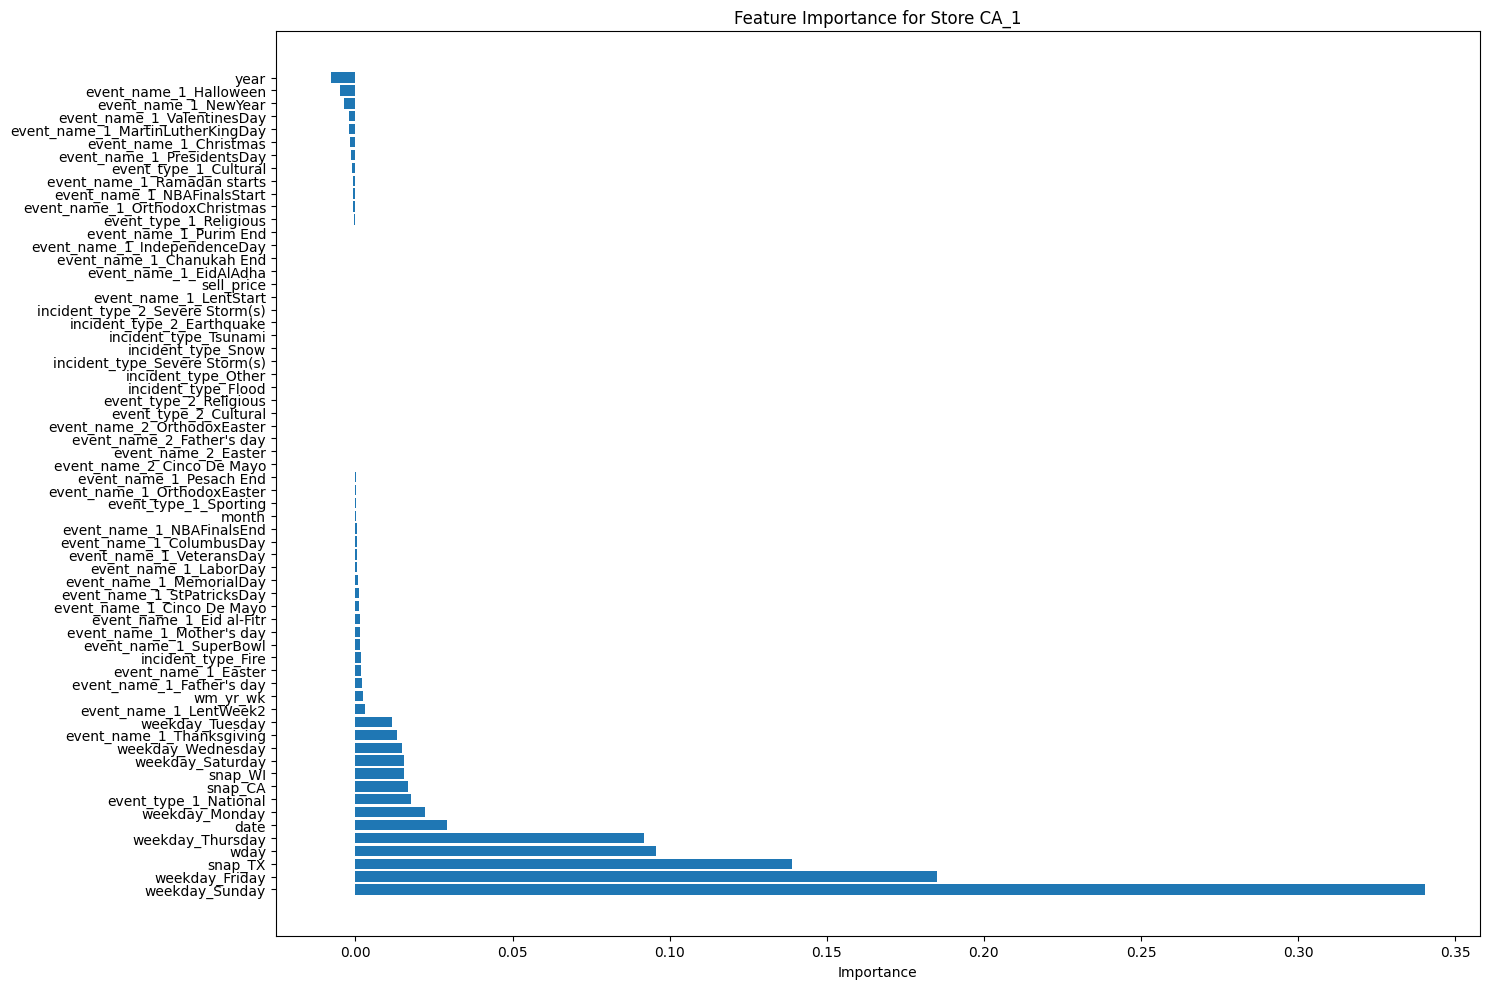

12/12 [==============================] - 0s 16ms/step
Evaluation Metrics for Store CA_1:
RMSE: 503.1843
MAE: 352.9141
MAPE: 55228207423027760.0000 or 5522820742302776320.00%
SMAPE: 8.18%
R²: 0.6923
NRMSE: 78830.16%


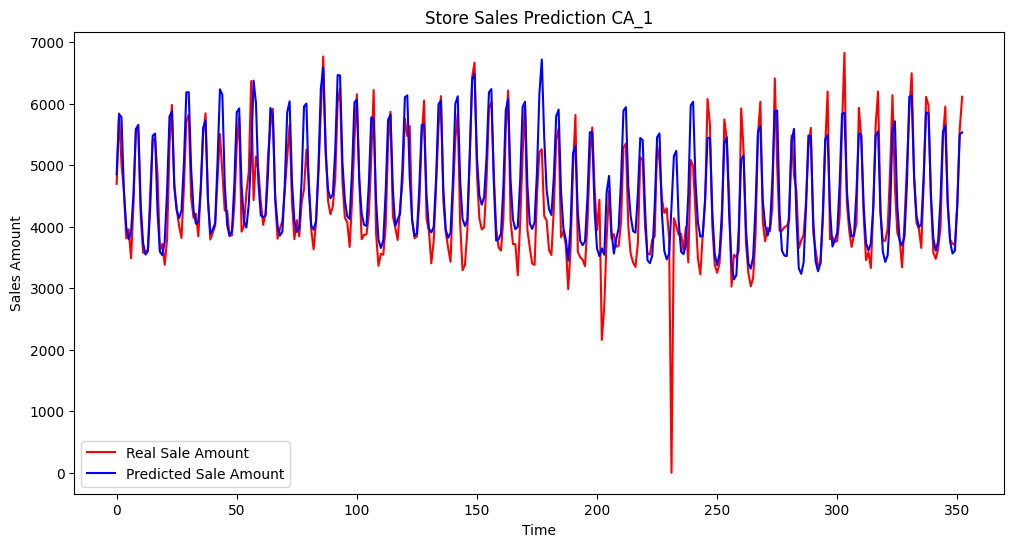

Train Done-----------------------------------------
Training begin CA_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0453
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0230
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0188
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0141
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0097
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0076
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0067
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0386
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0172
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0141
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0118
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0085
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0068
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0077
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0636
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0236
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0192
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0185
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0147
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0107
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0084
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0072
Epoch 10/10
38/38 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0473
Epoch 2/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0181
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0162
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0120
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0089
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0069
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0073
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0065
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0066
Epoch 10/10
38/38 [==============================] - 1s 7ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0453
Epoch 2/10
75/75 [==============================] - 1s 8ms/step - loss: 0.0192
Epoch 3/10
75/75 [==============================] - 1s 8ms/step - loss: 0.0153
Epoch 4/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0109
Epoch 5/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0081
Epoch 6/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0067
Epoch 7/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0061
Epoch 8/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0057
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0057
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store CA_2:
weekday_Sunday: 0.2573
weekday_Friday: 0.2268
date: 0.1889
weekday_Thursday: 0.0770
wday: 0.0767
weekday_Monday: 0.0428
weekday_Saturday: 0.0420
snap_TX: 0.0289
weekday_Tuesday: 0.0242
w

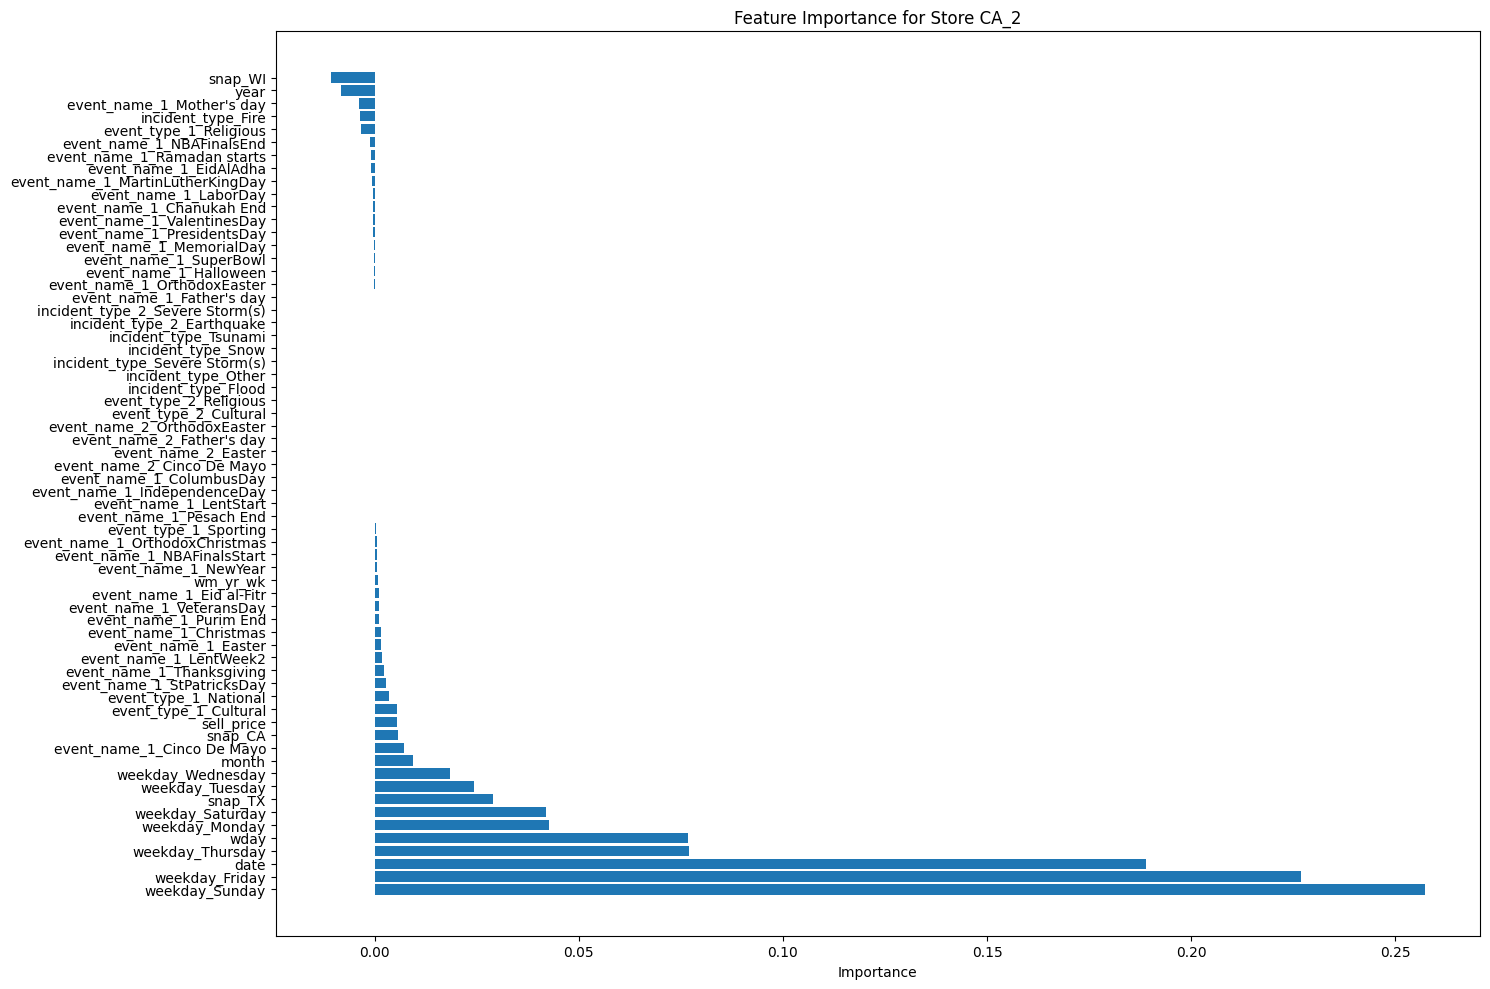

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store CA_2:
RMSE: 950.7243
MAE: 785.6790
MAPE: 4.7386 or 473.86%
SMAPE: 20.96%
R²: 0.2326
NRMSE: 116884.03%


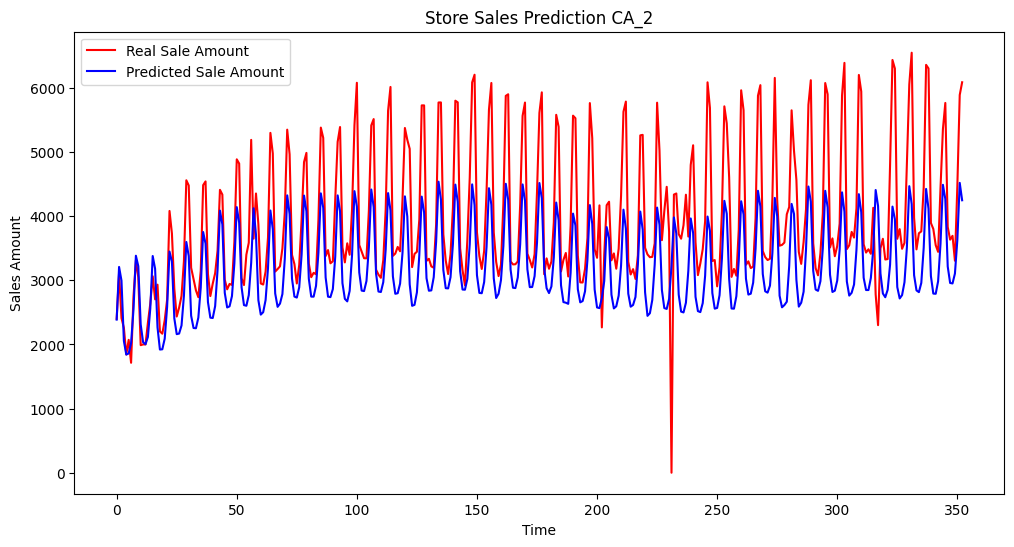

Train Done-----------------------------------------
Training begin CA_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 14ms/step - loss: 0.0423
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0164
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0135
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0124
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0112
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0089
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0079
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0375
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0112
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0105
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0084
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0072
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0064
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0060
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0672
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0170
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0158
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0136
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0110
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0104
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0087
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0082
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0367
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0122
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0104
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0095
Epoch 5/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0078
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0067
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0066
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0061
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0062
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0384
Epoch 2/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0129
Epoch 3/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0120
Epoch 4/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0099
Epoch 5/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0075
Epoch 6/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0070
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0065
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0063
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0060
Epoch 10/10
12/12 [==============================] - 0s 7ms/step

Feature Importance for Store CA_3:
weekday_Friday: 0.2805
weekday_Sunday: 0.2518
date: 0.0702
snap_TX: 0.0624
weekday_Monday: 0.0546
weekday_Saturday: 0.0474
snap_CA: 0.0463
weekday_Thursday: 0.0355
month: 0.0318
inci

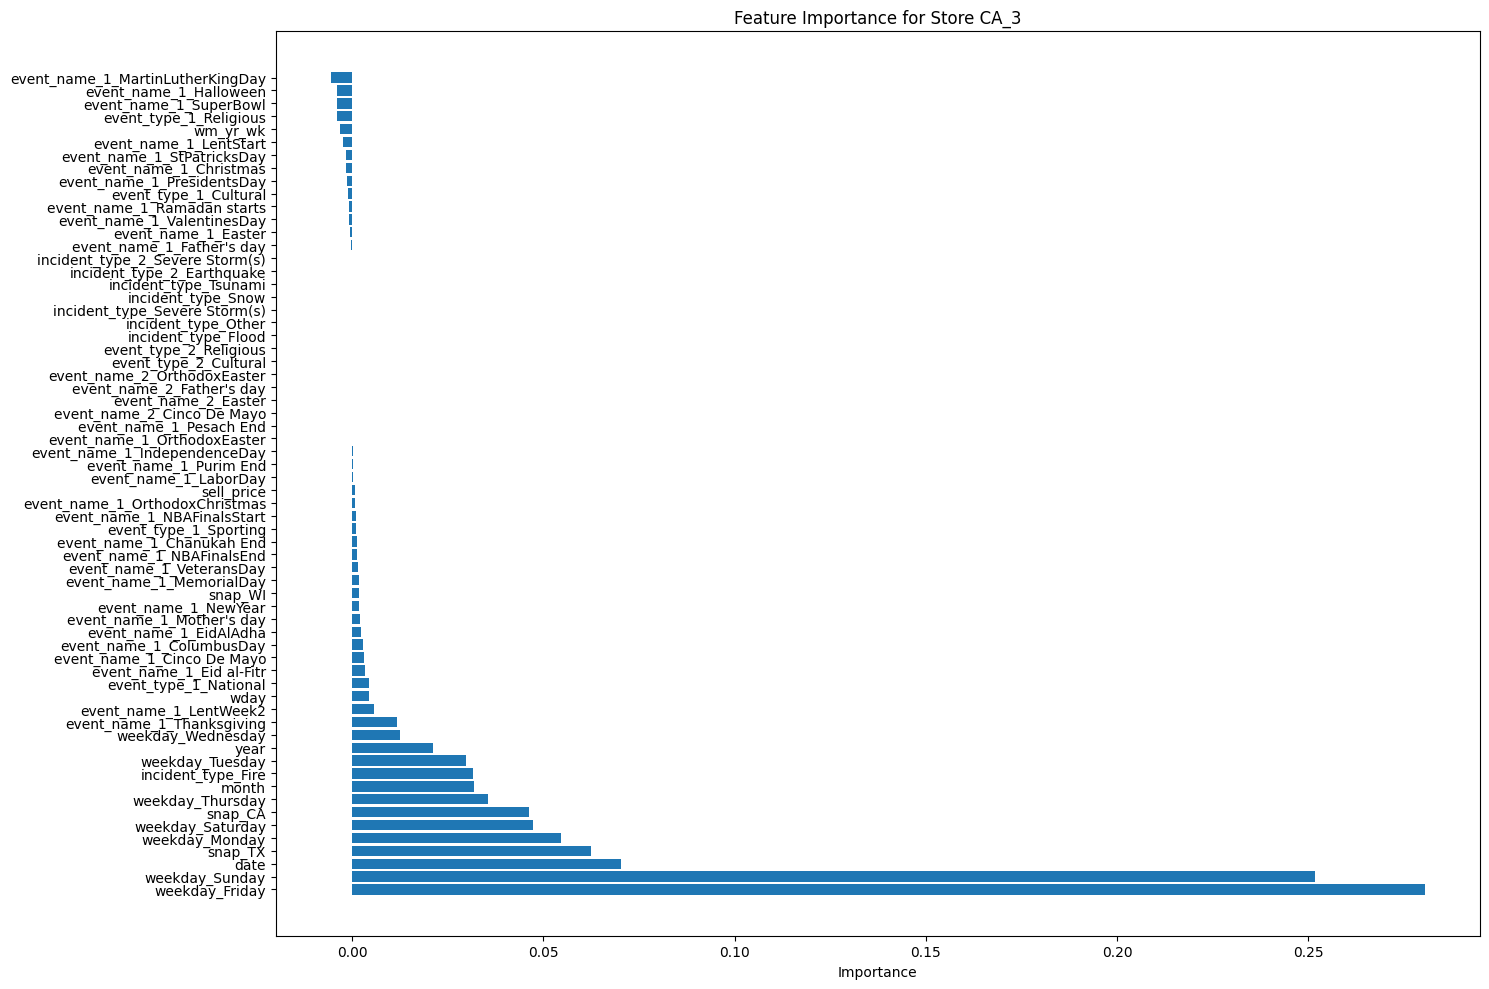

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store CA_3:
RMSE: 731.4860
MAE: 561.2316
MAPE: 4.1274 or 412.74%
SMAPE: 9.13%
R²: 0.5196
NRMSE: 108577.93%


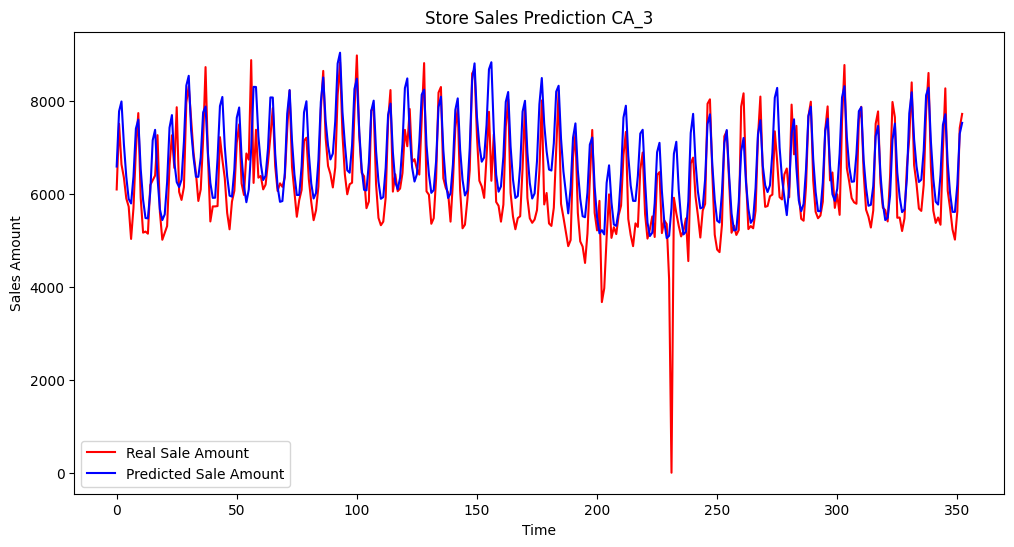

Train Done-----------------------------------------
Training begin CA_4--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0428
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0136
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0132
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0114
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0097
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0090
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0086
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0327
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0107
Epoch 3/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0094
Epoch 4/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0073
Epoch 6/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0062
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0060
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0691
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0143
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0132
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0112
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0117
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0099
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0081
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0085
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0082
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0354
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0105
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0090
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0080
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0077
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0066
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0062
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0058
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0056
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0346
Epoch 2/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0114
Epoch 3/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0097
Epoch 4/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0088
Epoch 5/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0085
Epoch 6/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0067
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0062
Epoch 8/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0065
Epoch 9/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0063
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store CA_4:
weekday_Friday: 0.2644
weekday_Sunday: 0.2239
weekday_Monday: 0.1012
month: 0.0993
weekday_Thursday: 0.0713
weekday_Tuesday: 0.0549
weekday_Saturday: 0.0418
incident_type_Fire: 0.0373
wda

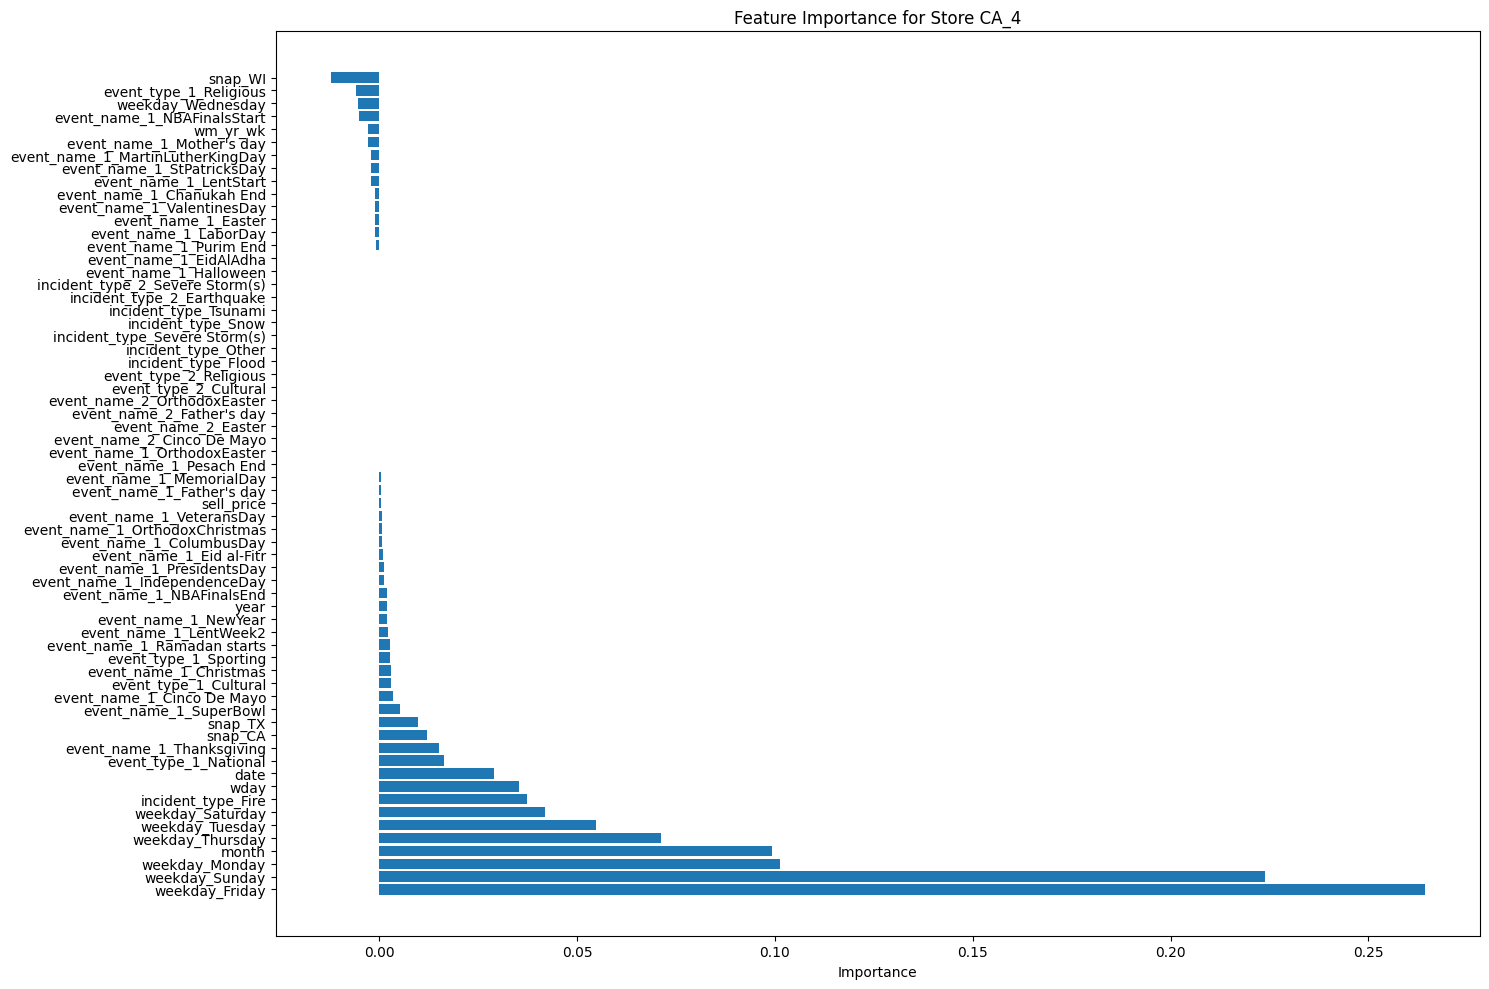

12/12 [==============================] - 0s 10ms/step
Evaluation Metrics for Store CA_4:
RMSE: 263.3429
MAE: 197.3067
MAPE: 25802113221084760.0000 or 2580211322108475904.00%
SMAPE: 8.51%
R²: 0.3229
NRMSE: 35222.46%


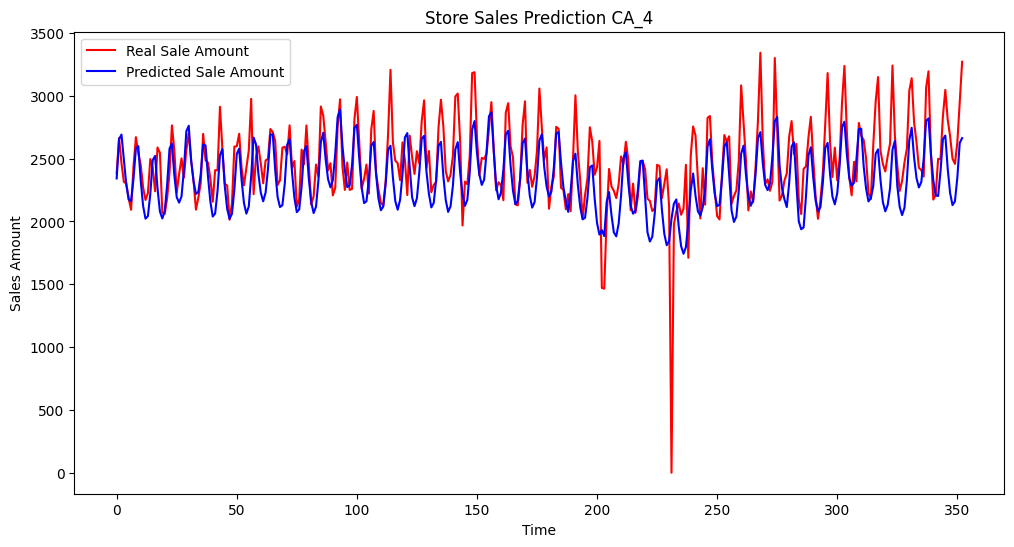

Train Done-----------------------------------------
Training begin TX_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 14ms/step - loss: 0.0408
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0175
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0161
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0125
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0105
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0087
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0083
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0429
Epoch 2/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0156
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0129
Epoch 4/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0124
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0097
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0089
Epoch 7/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0083
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 13ms/step - loss: 0.0670
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0202
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0182
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0145
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0133
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0120
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0097
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0085
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0429
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0147
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0134
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0111
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0107
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0087
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0081
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0077
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 11ms/step - loss: 0.0337
Epoch 2/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0146
Epoch 3/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0113
Epoch 4/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0084
Epoch 5/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0078
Epoch 6/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0078
Epoch 7/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0066
Epoch 8/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0068
Epoch 9/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0065
Epoch 10/10
12/12 [==============================] - 0s 4ms/step

Feature Importance for Store TX_1:
weekday_Sunday: 0.3944
weekday_Friday: 0.2574
weekday_Saturday: 0.0963
snap_TX: 0.0396
date: 0.0377
weekday_Monday: 0.0371
snap_WI: 0.0313
month: 0.0268
event_name_1_Thanksgiving:

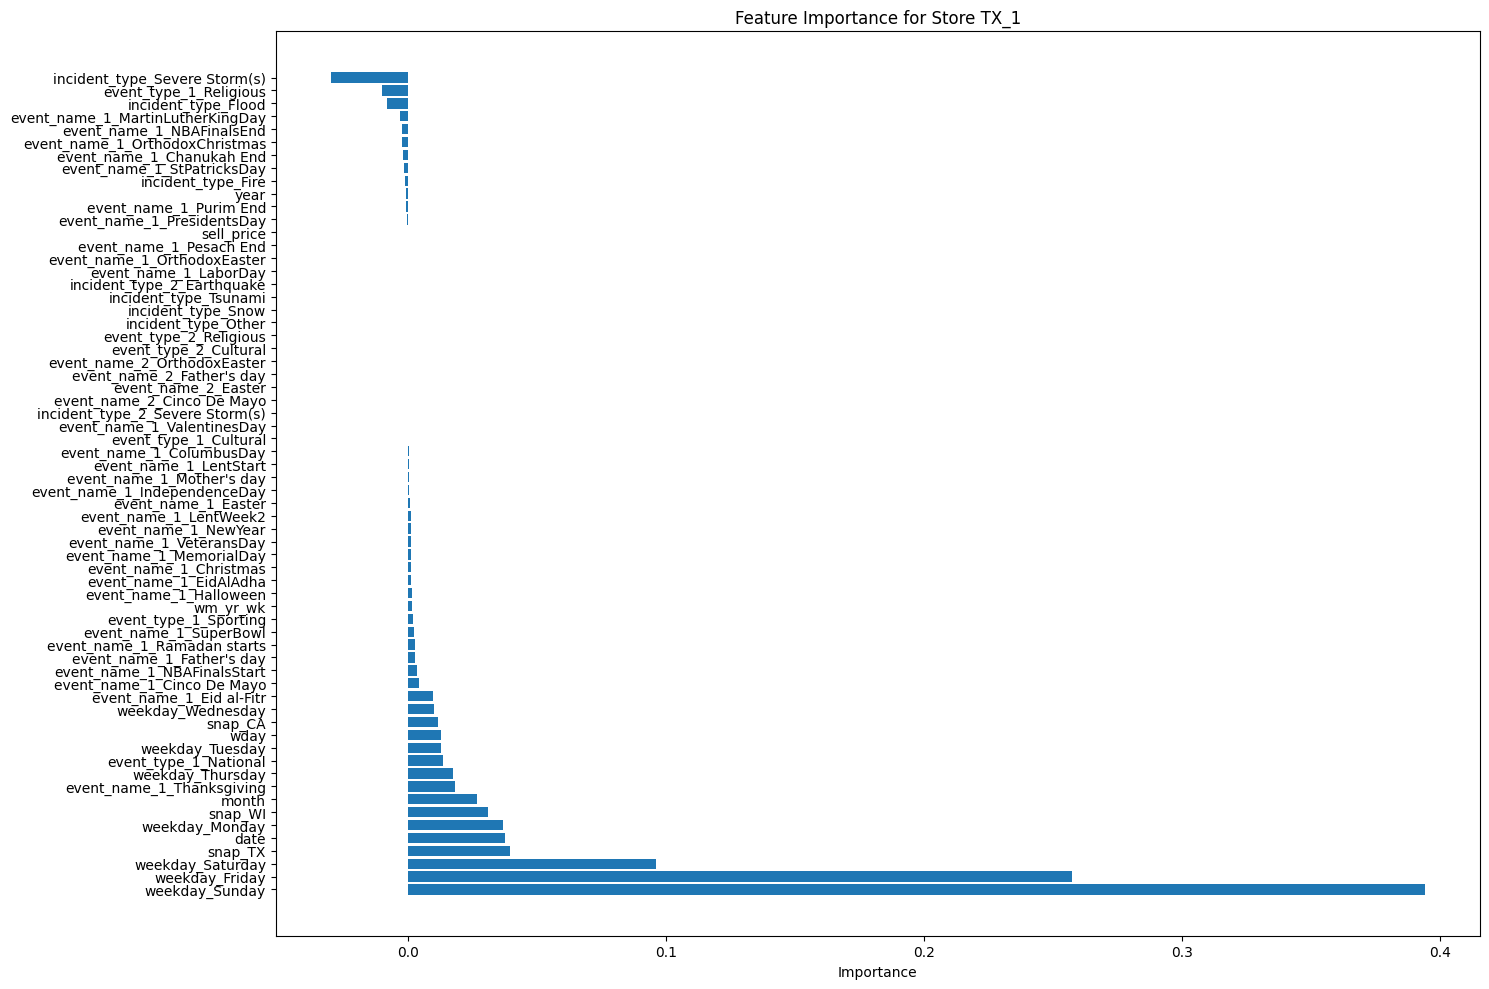

12/12 [==============================] - 0s 14ms/step
Evaluation Metrics for Store TX_1:
RMSE: 355.3531
MAE: 250.2035
MAPE: 8.0408 or 804.08%
SMAPE: 8.31%
R²: 0.5978
NRMSE: 52955.42%


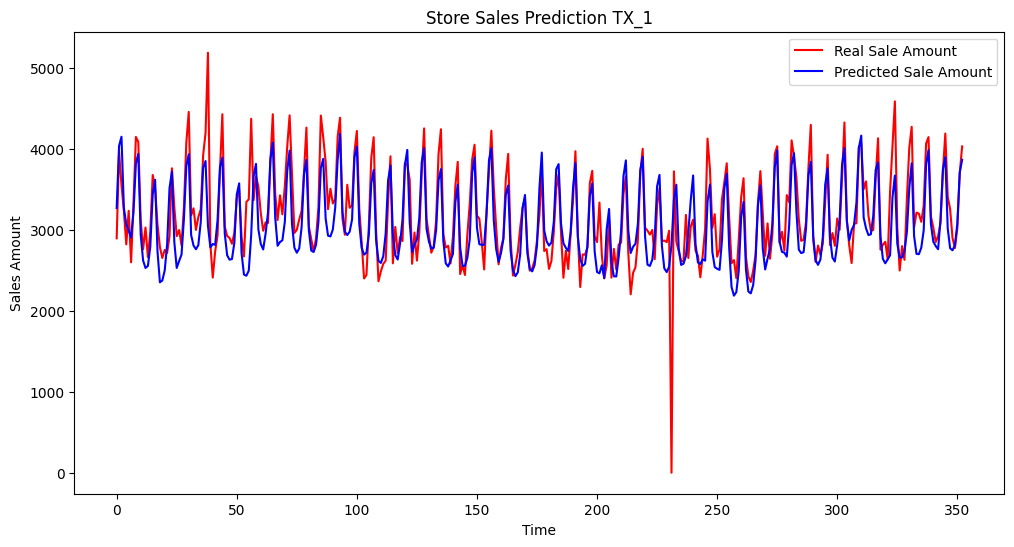

Train Done-----------------------------------------
Training begin TX_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 16ms/step - loss: 0.0393
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0188
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0153
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0129
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0104
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0086
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0078
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0470
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0162
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0140
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0122
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0116
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0093
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0080
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0691
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0214
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0160
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0142
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0120
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0112
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0099
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0085
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0090
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0461
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0163
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0138
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0115
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0097
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0104
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0076
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0074
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0068
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 11ms/step - loss: 0.0394
Epoch 2/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0152
Epoch 3/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0118
Epoch 4/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0098
Epoch 5/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0080
Epoch 6/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0082
Epoch 7/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0070
Epoch 8/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0075
Epoch 9/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0067
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store TX_2:
weekday_Sunday: 0.4218
weekday_Friday: 0.2762
weekday_Monday: 0.0868
month: 0.0751
date: 0.0539
snap_TX: 0.0389
wday: 0.0373
weekday_Saturday: 0.0359
weekday_Thursday: 0.0317
snap

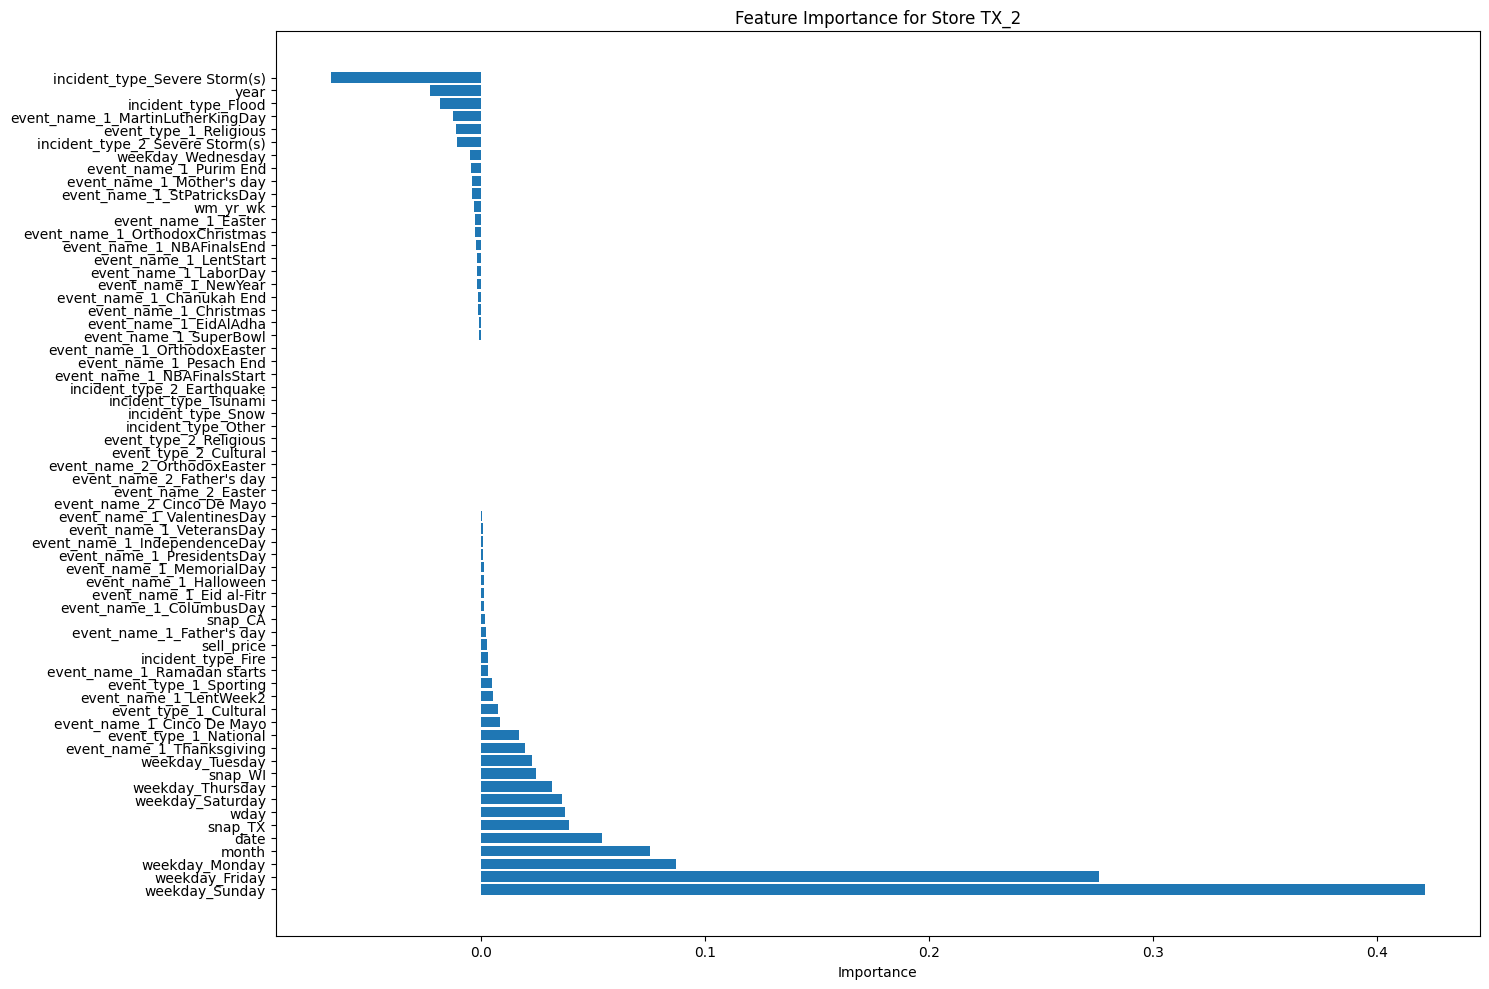

12/12 [==============================] - 0s 12ms/step
Evaluation Metrics for Store TX_2:
RMSE: 607.3412
MAE: 474.7897
MAPE: 39645106336538320.0000 or 3964510633653832192.00%
SMAPE: 13.56%
R²: 0.1766
NRMSE: 97964.43%


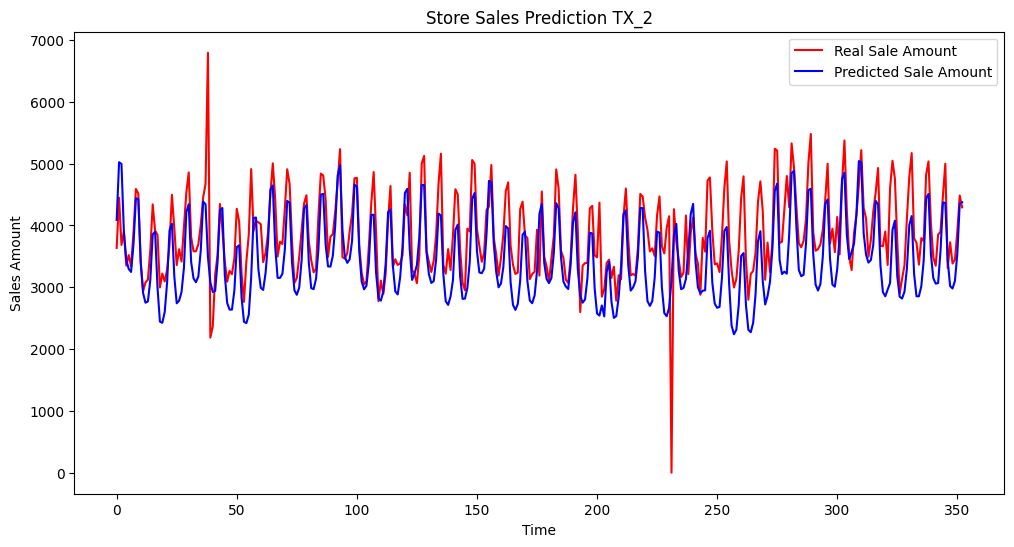

Train Done-----------------------------------------
Training begin TX_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0354
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0159
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0147
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0131
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0103
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0085
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0079
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0386
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0120
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0113
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0109
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0085
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0073
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0074
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0658
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0165
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0147
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0129
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0119
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0102
Epoch 7/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0092
Epoch 8/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0085
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0084
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0406
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0139
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0111
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0100
Epoch 5/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0086
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0062
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0064
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 4s 11ms/step - loss: 0.0320
Epoch 2/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0128
Epoch 3/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0103
Epoch 4/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0081
Epoch 5/8
94/94 [==============================] - 1s 13ms/step - loss: 0.0074
Epoch 6/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0075
Epoch 7/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0067
Epoch 8/8
12/12 [==============================] - 0s 7ms/step

Feature Importance for Store TX_3:
weekday_Sunday: 0.3312
weekday_Friday: 0.2478
weekday_Monday: 0.0943
weekday_Thursday: 0.0776
snap_WI: 0.0698
snap_TX: 0.0406
wday: 0.0347
weekday_Saturday: 0.0320
month: 0.0319
event_name_1_Thanksgiving: 0.0280
snap_CA: 0.0255
weekday_Tuesday: 0.0239
date: 0.0232
event_type_1_National: 0.0179
year: 0.0168
event_name_1_MemorialDay: 0.0086
event_n

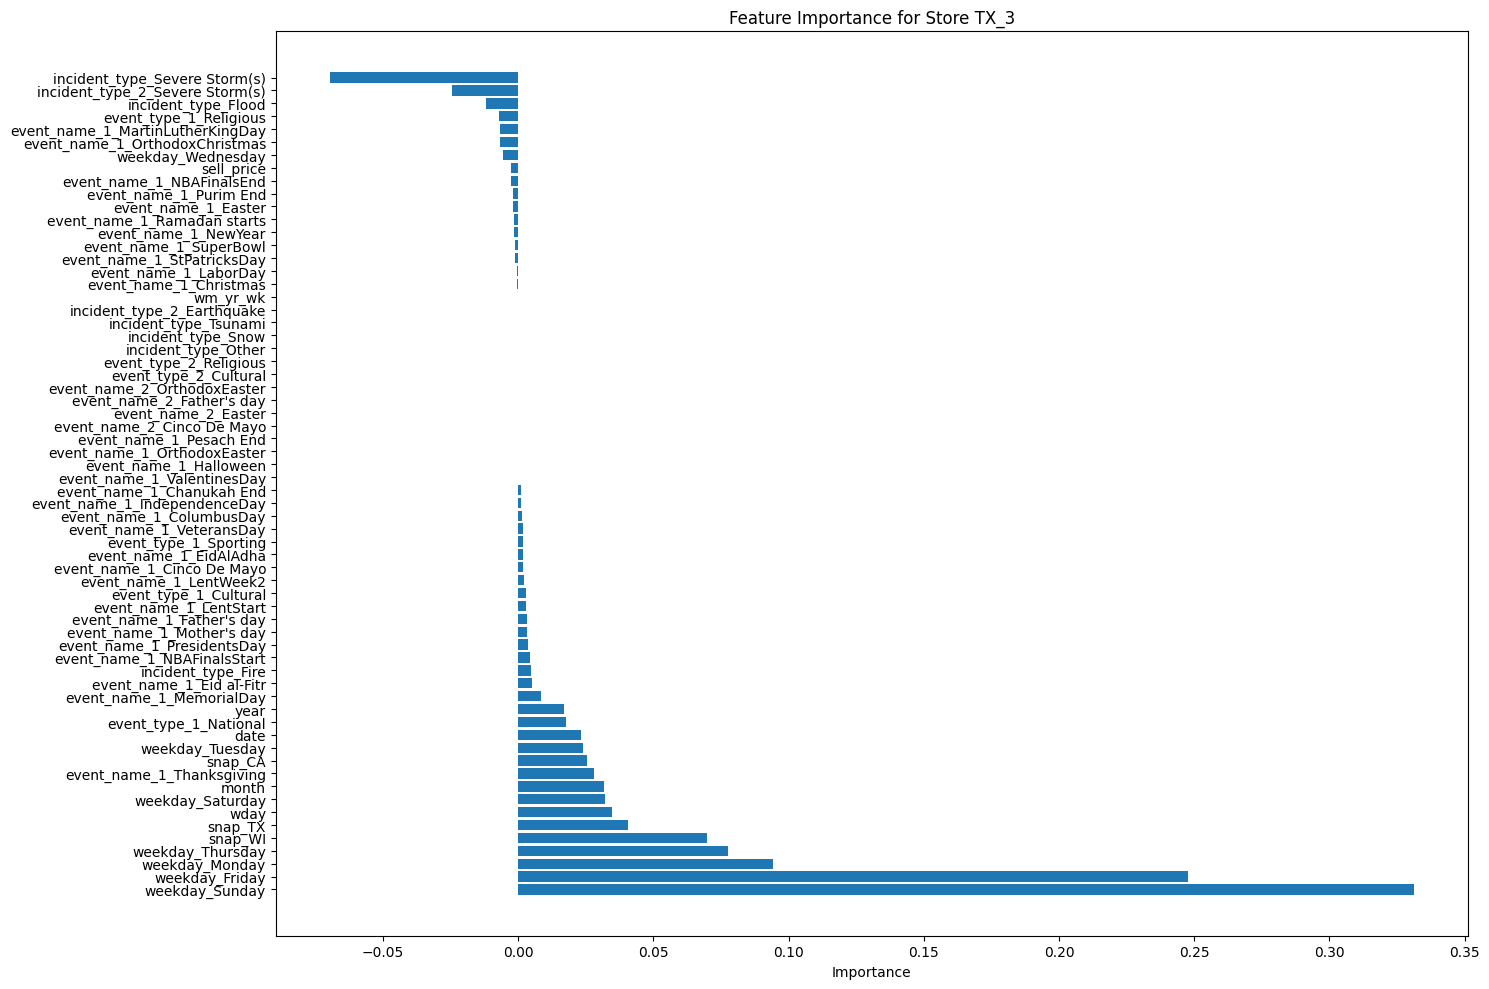

12/12 [==============================] - 0s 13ms/step
Evaluation Metrics for Store TX_3:
RMSE: 437.8910
MAE: 302.3676
MAPE: 3.3205 or 332.05%
SMAPE: 8.49%
R²: 0.4349
NRMSE: 58101.86%


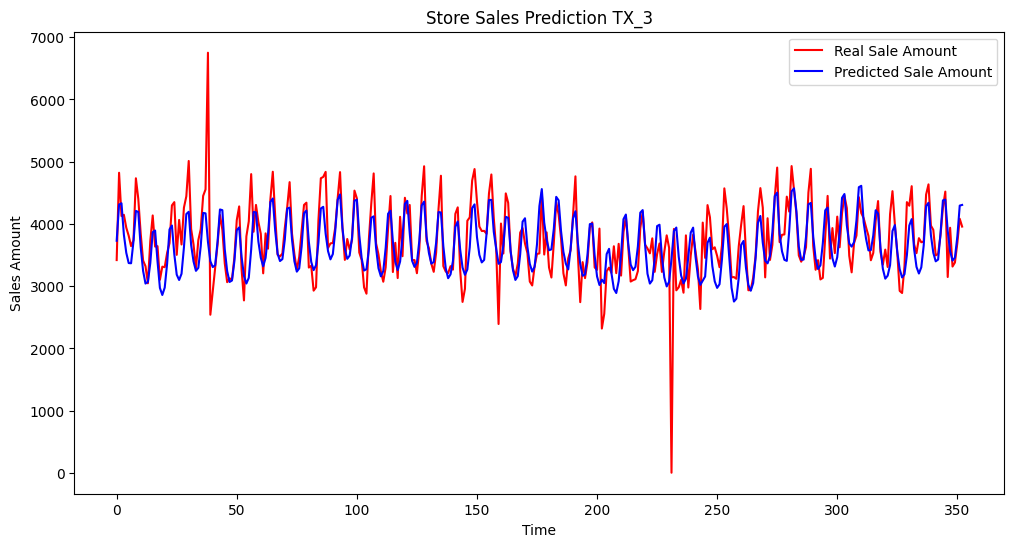

Train Done-----------------------------------------
Training begin WI_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0245
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0120
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0104
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0082
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0061
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0053
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0053
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 12ms/step - loss: 0.0122
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0057
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0050
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0044
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0040
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0035
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0033
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0393
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0130
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0118
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0095
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0081
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0069
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0063
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0049
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0050
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 12ms/step - loss: 0.0128
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0053
Epoch 3/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0048
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0041
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0046
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0037
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0032
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0032
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0031
Epoch 10/10
38/38 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 11ms/step - loss: 0.0160
Epoch 2/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0083
Epoch 3/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0064
Epoch 4/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0049
Epoch 5/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0045
Epoch 6/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0043
Epoch 7/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0038
Epoch 8/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0039
Epoch 9/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0035
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store WI_1:
weekday_Sunday: 0.3027
weekday_Friday: 0.2322
weekday_Saturday: 0.1473
weekday_Thursday: 0.1005
snap_TX: 0.0706
wday: 0.0370
year: 0.0297
weekday_Wednesday: 0.0199
snap_WI: 0.0164

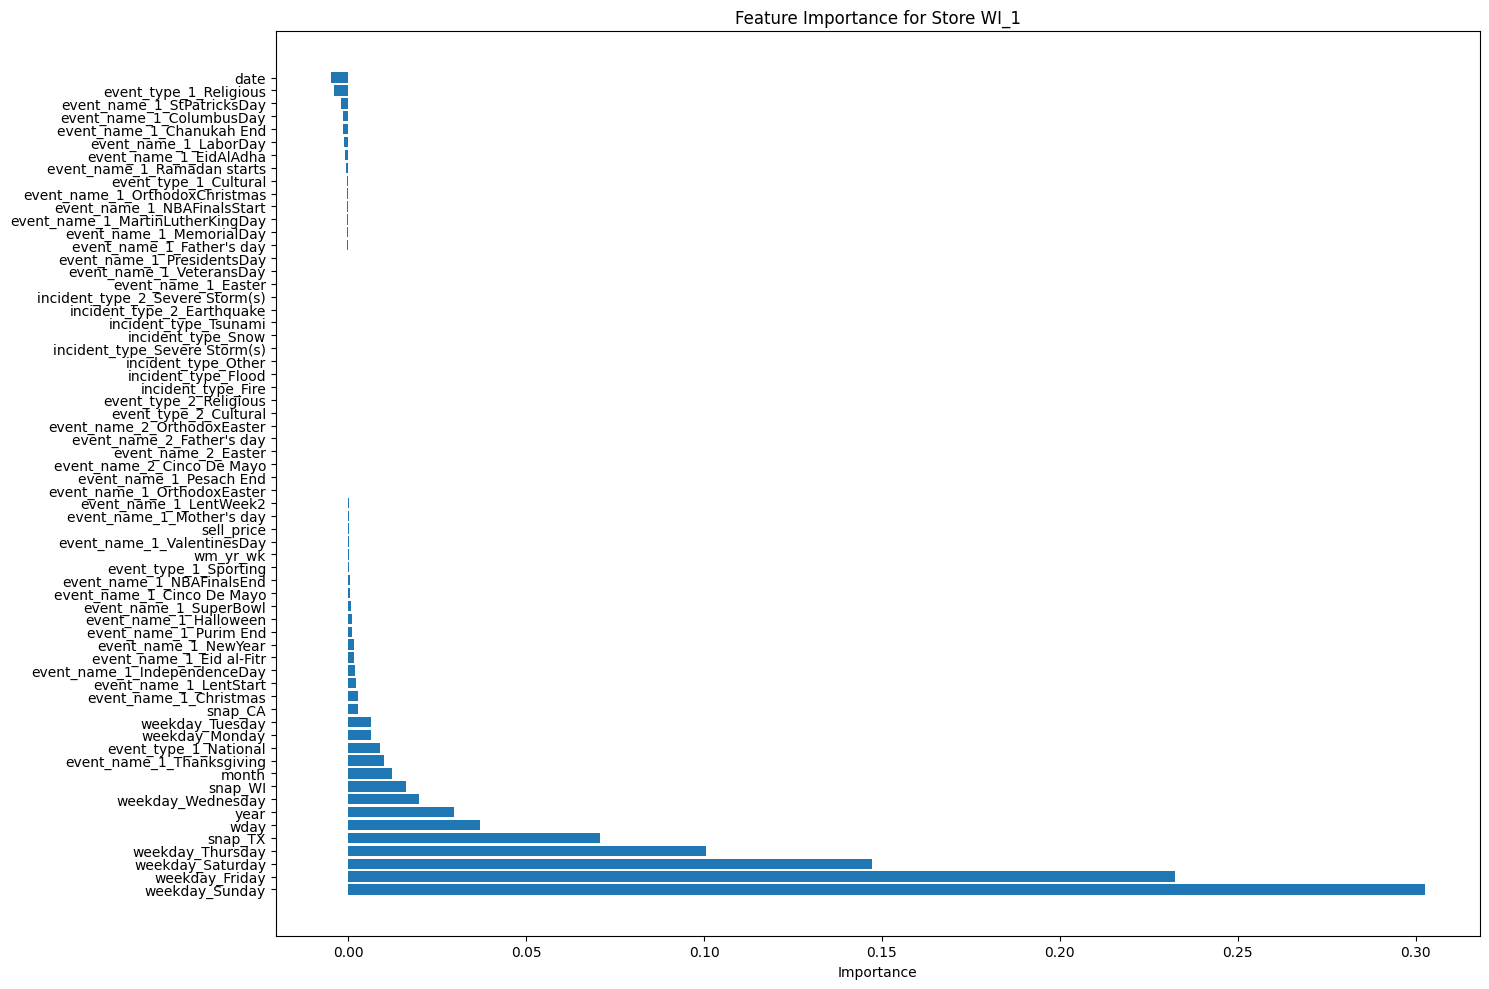

12/12 [==============================] - 0s 17ms/step
Evaluation Metrics for Store WI_1:
RMSE: 471.9687
MAE: 332.9162
MAPE: 5.3921 or 539.21%
SMAPE: 9.59%
R²: 0.6552
NRMSE: 90576.34%


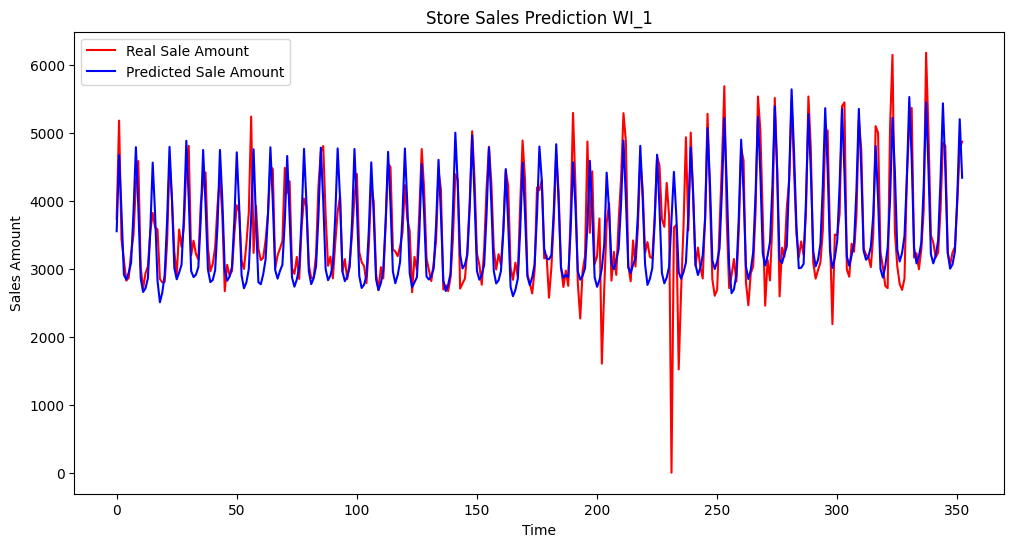

Train Done-----------------------------------------
Training begin WI_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0417
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0182
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0161
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0157
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0159
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0133
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0123
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0253
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0100
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0083
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0085
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0078
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0079
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0077
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0666
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0196
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0164
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0153
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0161
Epoch 6/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0133
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0122
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0127
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0124
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0304
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0098
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0084
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0076
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0076
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0073
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0061
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0066
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0345
Epoch 2/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0143
Epoch 3/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0128
Epoch 4/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0110
Epoch 5/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0105
Epoch 6/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0102
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0090
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0089
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0082
Epoch 10/10
12/12 [==============================] - 0s 5ms/step

Feature Importance for Store WI_2:
snap_WI: 0.2287
snap_TX: 0.2195
date: 0.2029
snap_CA: 0.1423
weekday_Sunday: 0.0403
weekday_Saturday: 0.0397
weekday_Thursday: 0.0337
weekday_Friday: 0.0200
weekday_Tuesday: 0.0160


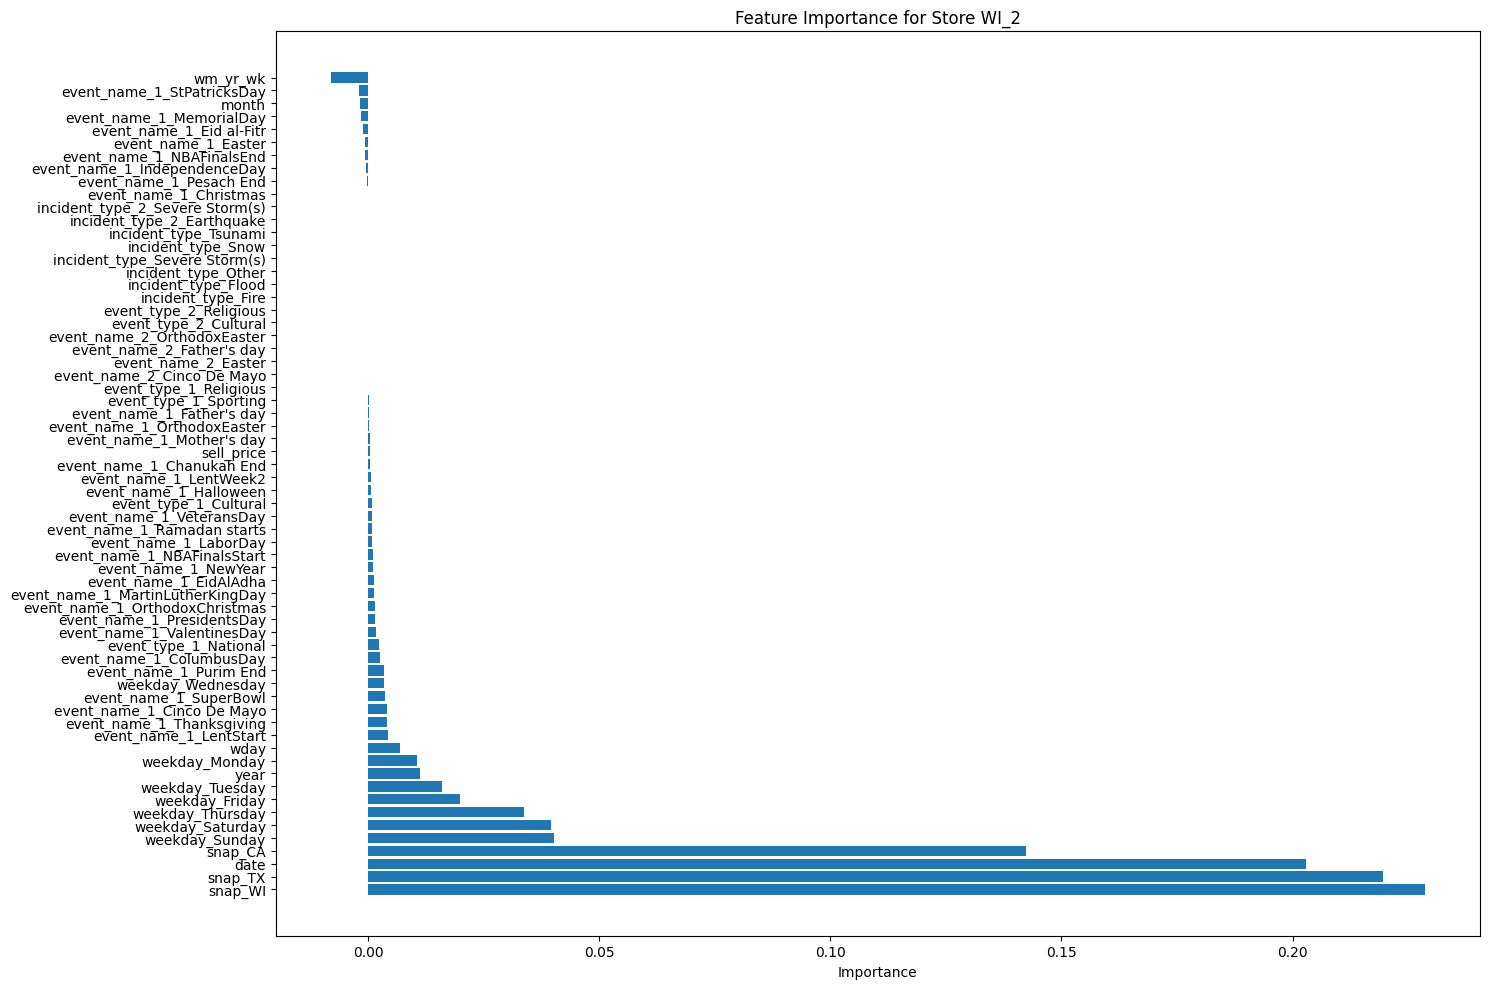

12/12 [==============================] - 0s 11ms/step
Evaluation Metrics for Store WI_2:
RMSE: 699.2243
MAE: 537.1337
MAPE: 9.6053 or 960.53%
SMAPE: 12.58%
R²: 0.5064
NRMSE: 96081.59%


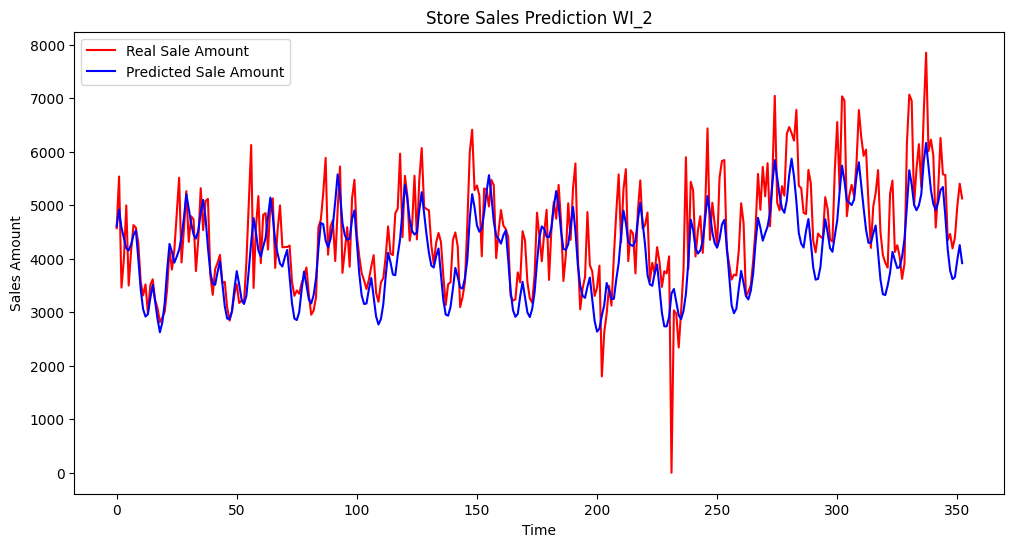

Train Done-----------------------------------------
Training begin WI_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0259
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0113
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0102
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0094
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0074
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0070
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0061
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0451
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0185
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0166
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0151
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0128
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0119
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0100
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 12ms/step - loss: 0.0448
Epoch 2/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0134
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0106
Epoch 4/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0095
Epoch 5/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0090
Epoch 6/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0075
Epoch 7/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0067
Epoch 8/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0061
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0060
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 14ms/step - loss: 0.0534
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0198
Epoch 3/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0176
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0145
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0124
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0119
Epoch 7/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0104
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0096
Epoch 9/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0104
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 14ms/step - loss: 0.0361
Epoch 2/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0141
Epoch 3/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0137
Epoch 4/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0099
Epoch 5/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0085
Epoch 6/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0082
Epoch 7/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0080
Epoch 8/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0074
Epoch 9/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0069
Epoch 10/10
12/12 [==============================] - 0s 6ms/step

Feature Importance for Store WI_3:
snap_TX: 0.2651
snap_WI: 0.1450
weekday_Sunday: 0.1329
snap_CA: 0.0872
date: 0.0819
weekday_Thursday: 0.0795
weekday_Friday: 0.0587
weekday_Saturday: 0.0503
wday: 0.0416
month: 0.

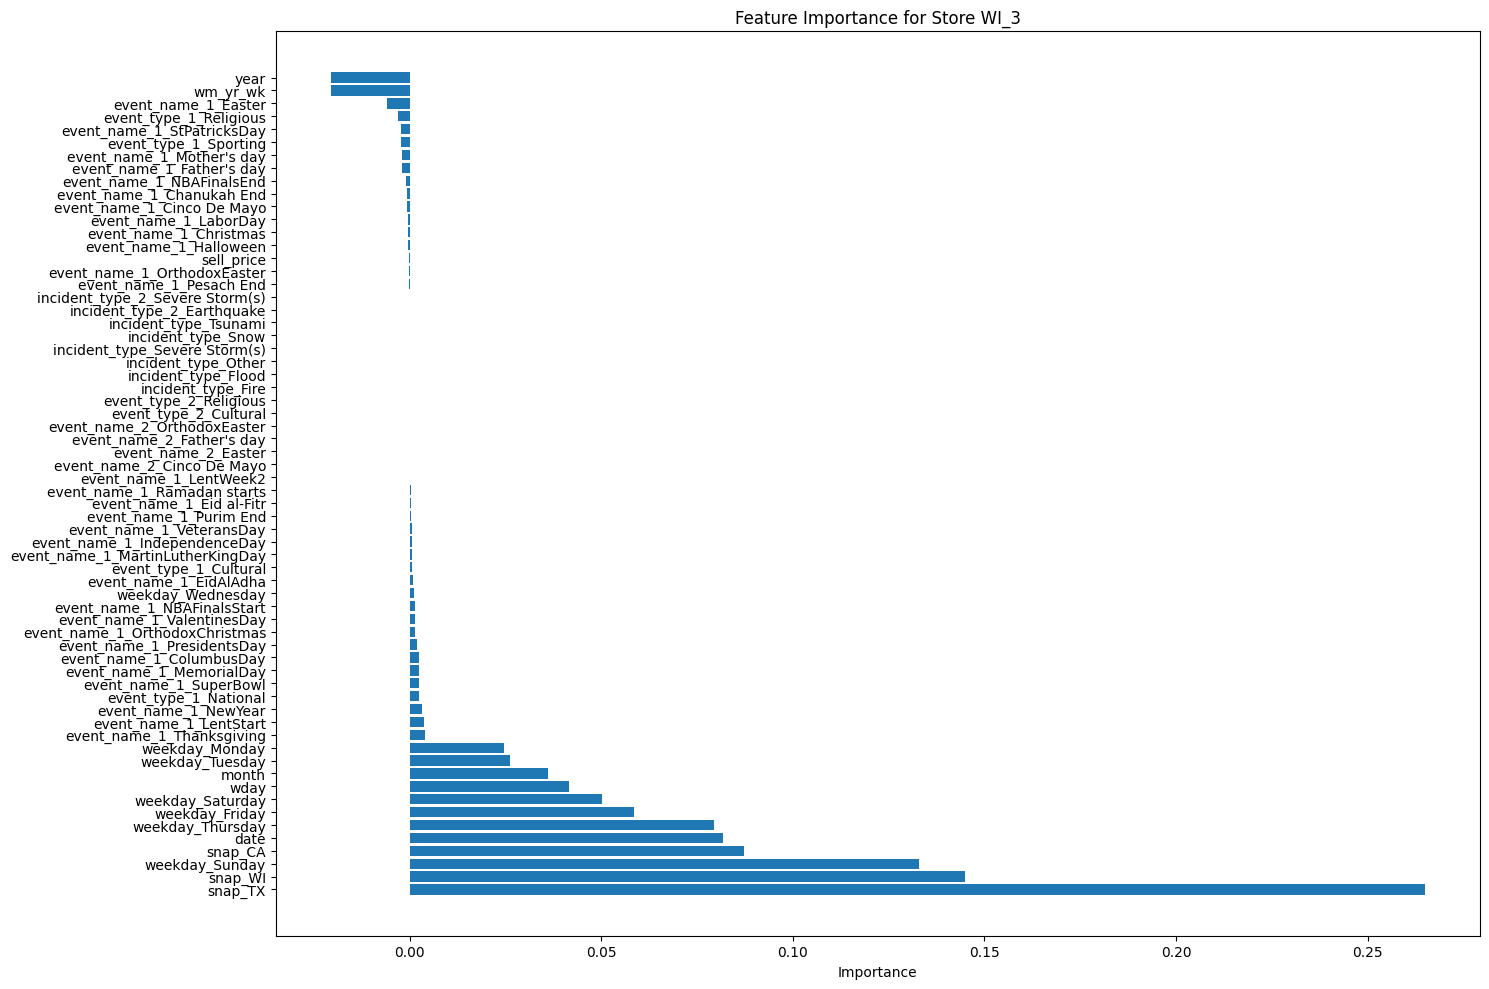

12/12 [==============================] - 0s 8ms/step
Evaluation Metrics for Store WI_3:
RMSE: 688.0388
MAE: 542.4895
MAPE: 8.2807 or 828.07%
SMAPE: 16.12%
R²: 0.1445
NRMSE: 118349.56%


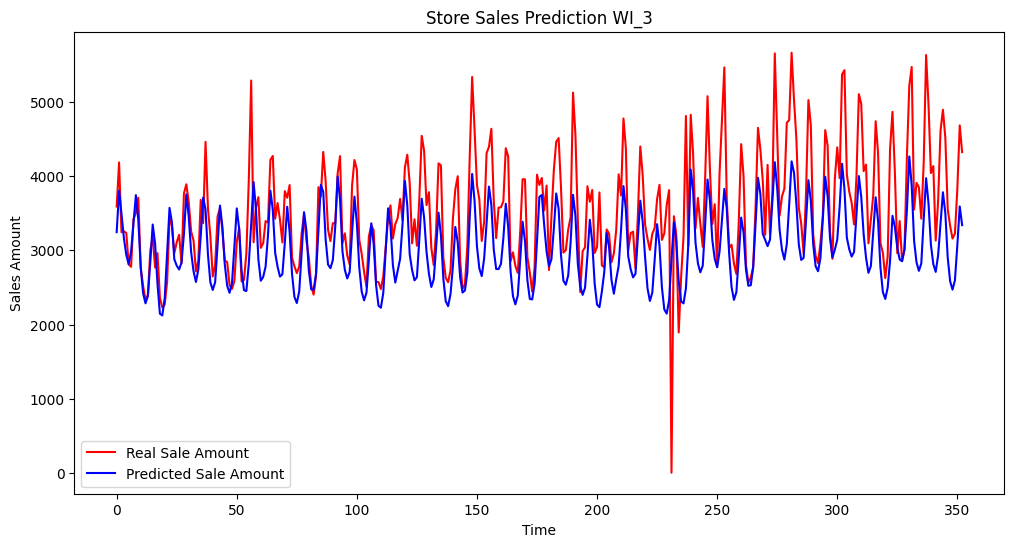

Train Done-----------------------------------------

Metrics Comparison Across All Stores:
            RMSE         MAE          MAPE      SMAPE        R²          NRMSE
CA_1  503.184299  352.914069  5.522821e+16   8.178589  0.692277   78830.164884
CA_2  950.724251  785.679040  4.738630e+00  20.962715  0.232595  116884.030373
CA_3  731.485954  561.231563  4.127449e+00   9.126005  0.519620  108577.926718
CA_4  263.342939  197.306690  2.580211e+16   8.506544  0.322893   35222.458847
TX_1  355.353071  250.203463  8.040776e+00   8.313527  0.597753   52955.415106
TX_2  607.341200  474.789731  3.964511e+16  13.557377  0.176579   97964.428117
TX_3  437.891034  302.367636  3.320539e+00   8.494273  0.434860   58101.857257
WI_1  471.968706  332.916225  5.392057e+00   9.587061  0.655151   90576.339395
WI_2  699.224277  537.133690  9.605255e+00  12.575140  0.506377   96081.590549
WI_3  688.038797  542.489507  8.280685e+00  16.124972  0.144525  118349.563070


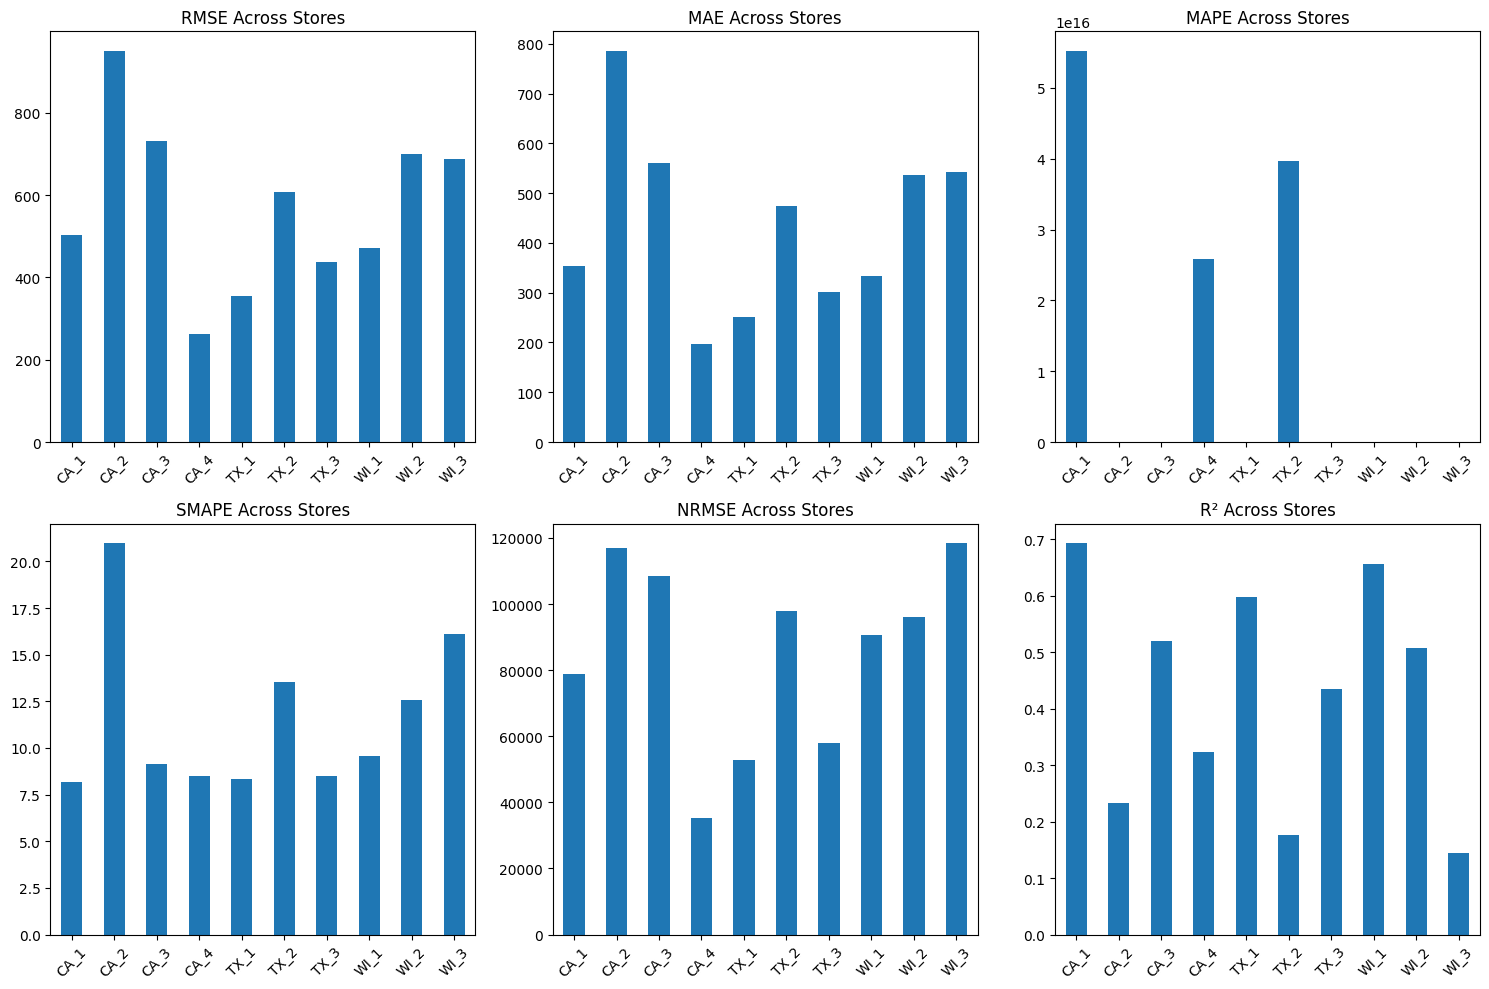

In [ ]:
#%%

dir = "../data/df_encoded.csv"
df = pd.read_csv(dir)
store_list = df["store_id"].unique()
scaler = MinMaxScaler(feature_range=(0,1))
metrics_results = {}
features = {}
predict = {}
for store in store_list:
    print(f"Training begin {store}--------------------------------")
    trainX, trainY, testX, testY = prepare_data(dir, store)
    grid_search = train_model(build_model, trainX, trainY)
    my_model = grid_search.best_estimator_.model_
    
    feature_cols = [col for col in df.columns if col not in ['store_id', 'sold','count']]
    
    # Calculate and store feature importance
    feature_importance = calculate_feature_importance(store, my_model, testX, testY, feature_cols)
    
    # Store in your metrics results
    features[store] = {'features': feature_importance}


    # Make predictions
    predictions = my_model.predict(testX)
    
    # Inverse transform for actual values (same as your original code)
    prediction_copies_array = np.repeat(predictions, 64, axis=-1)
    pred = scaler.inverse_transform(np.reshape(prediction_copies_array, (len(predictions), 64)))[:,0]
    predict[store] = {"predict": pred}
    original_copies_array = np.repeat(testY, 64, axis=-1)
    original = scaler.inverse_transform(np.reshape(original_copies_array, (len(testY), 64)))[:,0]
    
    # Calculate multiple evaluation metrics
    # 1. RMSE - Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(original, pred))
    
    # 2. MAE - Mean Absolute Error
    mae = mean_absolute_error(original, pred)
    
    # 3. MAPE - Mean Absolute Percentage Error (on original scale)
    # Avoiding division by zero
    mape = mean_absolute_percentage_error(original, pred)
    
    # 4. R² - Coefficient of Determination
    r2 = r2_score(original, pred)
    
    # 5. NRMSE - Normalized RMSE (as percentage of the mean)
    nrmse = rmse / np.mean(testY) * 100
    
    # 6. SMAPE - Symmetric Mean Absolute Percentage Error
    smape = 100/len(original) * np.sum(2 * np.abs(pred - original) / (np.abs(original) + np.abs(pred)))
    
    # Store all metrics
    metrics_results[store] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'SMAPE': smape,
        'R²': r2,
        'NRMSE': nrmse
    }
    
    # Print metrics
    print(f"Evaluation Metrics for Store {store}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f} or {mape*100:.2f}%")
    print(f"SMAPE: {smape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"NRMSE: {nrmse:.2f}%")
    
    # Plot actual vs predicted values (same as your original code)
    plt.figure(figsize=(12, 6))
    plt.plot(original, color='red', label='Real Sale Amount')
    plt.plot(pred, color='blue', label='Predicted Sale Amount')
    plt.title(f'Store Sales Prediction {store}')
    plt.xlabel('Time')
    plt.ylabel('Sales Amount')
    plt.legend()
    plt.show()
    
    print("Train Done-----------------------------------------")

# Create a comparison table of metrics across all stores
metrics_df = pd.DataFrame(metrics_results).T
print("\nMetrics Comparison Across All Stores:")
print(metrics_df)

predict = pd.DataFrame(predict)
predict.to_csv("../output/LSTM_output_result.csv")

# Plot metrics comparison
plt.figure(figsize=(15, 10))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'SMAPE', 'NRMSE']

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 3, i)
    metrics_df[metric].plot(kind='bar')
    plt.title(f'{metric} Across Stores')
    plt.xticks(rotation=45)
    plt.tight_layout()

# Plot R² separately (as it has a different scale)
plt.subplot(2, 3, 6)
metrics_df['R²'].plot(kind='bar')
plt.title('R² Across Stores')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('metrics_comparison.png')
plt.show()